# Building the Complete Transformer

Packages used in this notebook:

In [1]:
from importlib.metadata import version

print("torch version:", version("torch"))
print("matplotlib version:", version("matplotlib"))
print("numpy version:", version("numpy"))

torch version: 2.8.0
matplotlib version: 3.10.8
numpy version: 2.3.2


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

torch.manual_seed(42)

## Overview: The Complete Transformer

The previous notebooks built each piece of the Transformer in isolation:

| Notebook | What was built |
|----------|---------------|
| 01 | Tokenization, embeddings, data sampling |
| 02 | Scaled dot-product attention, causal masking, multi-head attention |
| 03 | Transformer Encoder (bidirectional self-attention) |
| 04 | Transformer Decoder (masked self-attention + cross-attention) + GPT-style variant |

This notebook assembles all of those components into the **complete Transformer** from the original "Attention Is All You Need" (Vaswani et al., 2017) — a unified **encoder-decoder** model designed for sequence-to-sequence tasks like machine translation.

### The big picture

```
Source sequence  ──▶  Encoder  ──▶  Encoder output (memory)
                                            │
                                            ▼ (K, V for cross-attention)
Target sequence  ──▶  Decoder  ──▶  Output logits
```

The encoder reads the entire source sequence and produces a rich, contextualized representation of it — the "memory". The decoder then generates the target sequence one token at a time, attending to both its own previous outputs (masked self-attention) and the encoder memory (cross-attention).

Three things are new in this notebook:
1. A unified `Transformer` class that wraps encoder and decoder
2. **Teacher forcing** — how the model is trained on seq2seq tasks
3. **Autoregressive inference** — how the model generates at test time

### Architecture Diagram

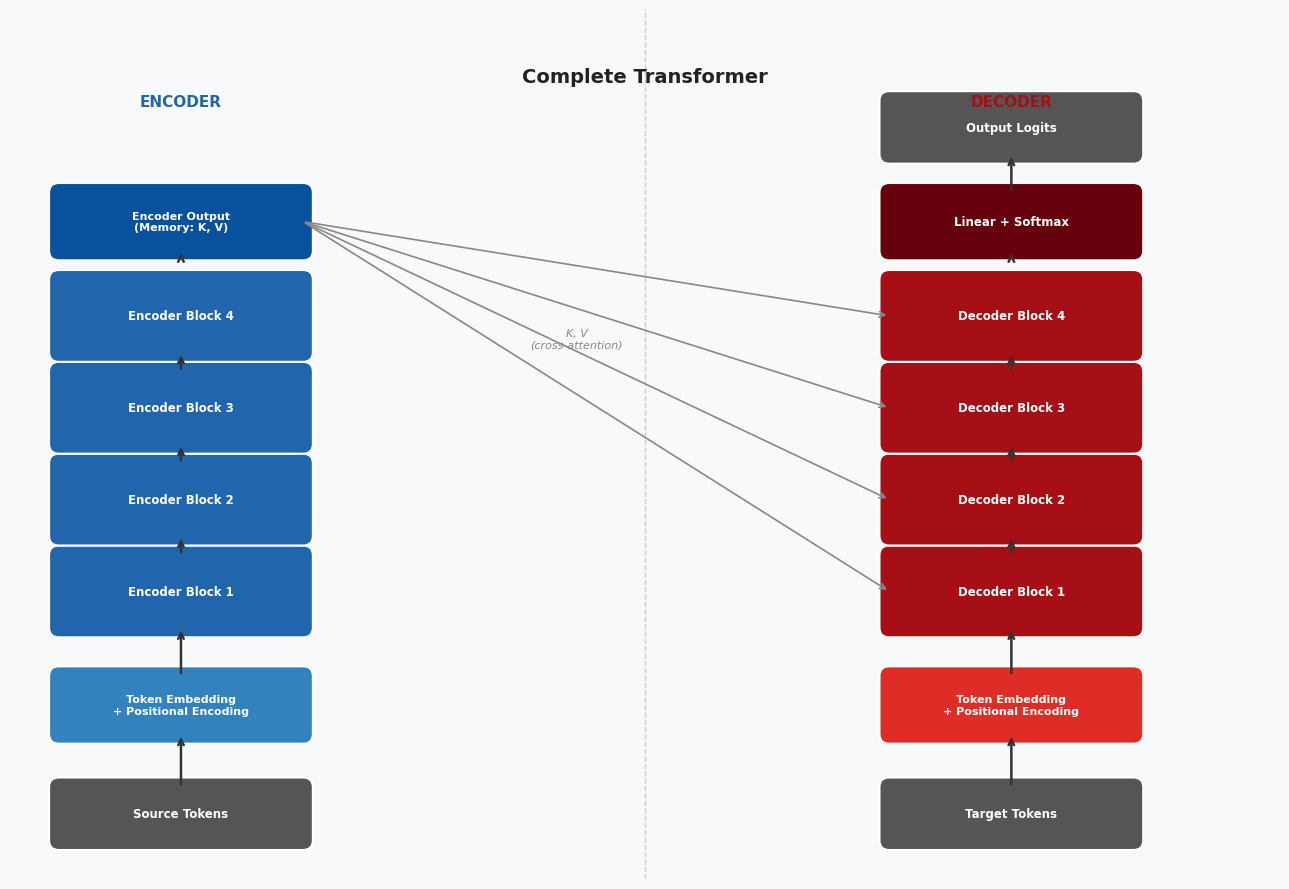

In [3]:
fig, ax = plt.subplots(figsize=(13, 9))
ax.set_xlim(0, 13)
ax.set_ylim(0, 9)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

def box(ax, x, y, w, h, label, color="#4C72B0", text_color="white", fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle="round,pad=0.1", facecolor=color, edgecolor="white", linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color=text_color)

def arrow(ax, x1, y1, x2, y2, label="", color="#333333"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", color=color, lw=1.8))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx + 0.1, my, label, fontsize=7.5, color=color, va="center")

# ── ENCODER SIDE (left) ──
enc_color  = "#2166ac"
enc_colors = ["#4393c3", "#4393c3", "#4393c3", "#4393c3"]

box(ax, 0.5, 0.4, 2.5, 0.55, "Source Tokens", "#555555", fontsize=8.5)
arrow(ax, 1.75, 0.95, 1.75, 1.5)
box(ax, 0.5, 1.5, 2.5, 0.6, "Token Embedding\n+ Positional Encoding", "#3182bd", fontsize=8)
arrow(ax, 1.75, 2.1, 1.75, 2.6)

for i, label in enumerate(["Encoder Block 1", "Encoder Block 2", "Encoder Block 3", "Encoder Block 4"]):
    yb = 2.6 + i * 0.95
    box(ax, 0.5, yb, 2.5, 0.75, label, enc_color, fontsize=8.5)
    if i < 3:
        arrow(ax, 1.75, yb + 0.75, 1.75, yb + 0.95)

box(ax, 0.5, 6.5, 2.5, 0.6, "Encoder Output\n(Memory: K, V)", "#08519c", fontsize=8)
arrow(ax, 1.75, 6.4, 1.75, 6.5)

# ── DECODER SIDE (right) ──
dec_color = "#a50f15"
box(ax, 9.0, 0.4, 2.5, 0.55, "Target Tokens", "#555555", fontsize=8.5)
arrow(ax, 10.25, 0.95, 10.25, 1.5)
box(ax, 9.0, 1.5, 2.5, 0.6, "Token Embedding\n+ Positional Encoding", "#de2d26", fontsize=8)
arrow(ax, 10.25, 2.1, 10.25, 2.6)

for i, label in enumerate(["Decoder Block 1", "Decoder Block 2", "Decoder Block 3", "Decoder Block 4"]):
    yb = 2.6 + i * 0.95
    box(ax, 9.0, yb, 2.5, 0.75, label, dec_color, fontsize=8.5)
    if i < 3:
        arrow(ax, 10.25, yb + 0.75, 10.25, yb + 0.95)

arrow(ax, 10.25, 6.4, 10.25, 6.5)
box(ax, 9.0, 6.5, 2.5, 0.6, "Linear + Softmax", "#67000d", fontsize=8.5)
arrow(ax, 10.25, 7.1, 10.25, 7.5)
box(ax, 9.0, 7.5, 2.5, 0.55, "Output Logits", "#555555", fontsize=8.5)

# ── CROSS-ATTENTION ARROWS (encoder → each decoder block) ──
enc_out_x = 3.0
enc_out_y = 6.8
for i in range(4):
    yb = 2.6 + i * 0.95 + 0.375
    ax.annotate("", xy=(9.0, yb), xytext=(3.0, enc_out_y),
        arrowprops=dict(arrowstyle="->", color="#888888", lw=1.2,
                        connectionstyle="arc3,rad=0.0"))

ax.text(6.5, 8.3, "Complete Transformer", ha="center", va="center",
        fontsize=14, fontweight="bold", color="#222222")
ax.text(1.75, 8.0, "ENCODER", ha="center", fontsize=11, fontweight="bold", color=enc_color)
ax.text(10.25, 8.0, "DECODER", ha="center", fontsize=11, fontweight="bold", color=dec_color)
ax.text(5.8, 5.5, "K, V\n(cross-attention)", ha="center", fontsize=8, color="#888888",
        style="italic")

ax.axvline(x=6.5, color="#cccccc", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

## Building Blocks (Recap)

The following classes were built in detail in notebooks 03 and 04. They are reproduced here so this notebook is self-contained. Explanations are kept brief — see the earlier notebooks for step-by-step walkthroughs.

---

### Shared Components

In [4]:
class SinusoidalPositionalEncoding(nn.Module):
    """Fixed sin/cos positional encoding (Vaswani et al. 2017)."""
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class LayerNorm(nn.Module):
    """Custom layer normalization with learnable scale and shift."""
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta  = nn.Parameter(torch.zeros(d_model))
        self.eps   = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std  = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta


class FeedForward(nn.Module):
    """Position-wise FFN: expand → ReLU → compress."""
    def __init__(self, d_model, d_ff, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)

### Encoder Components

In [5]:
class MultiHeadAttention(nn.Module):
    """Bidirectional multi-head self-attention (no causal mask) — used in the Encoder."""
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, T, D = x.shape
        def split_heads(t):
            return t.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split_heads(self.W_q(x)), split_heads(self.W_k(x)), split_heads(self.W_v(x))
        scores = (Q @ K.transpose(-2, -1)) * self.scale
        weights = self.dropout(torch.softmax(scores, dim=-1))
        out = (weights @ V).transpose(1, 2).reshape(B, T, D)
        return self.W_o(out), weights.detach()


class EncoderBlock(nn.Module):
    """Single Transformer Encoder block: self-attention + FFN, each with residual + LayerNorm."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_w = self.attn(x)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x, attn_w


class TransformerEncoder(nn.Module):
    """Full Transformer Encoder: embedding + PE + N encoder blocks."""
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe        = SinusoidalPositionalEncoding(d_model, max_len)
        self.blocks    = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm  = LayerNorm(d_model)
        self.scale = d_model ** 0.5

    def forward(self, x):
        x = self.pe(self.embedding(x) * self.scale)
        all_attn = []
        for block in self.blocks:
            x, attn_w = block(x)
            all_attn.append(attn_w)
        return self.norm(x), all_attn

### Decoder Components

In [6]:
class MaskedMultiHeadSelfAttention(nn.Module):
    """Causal (masked) multi-head self-attention — used in the Decoder."""
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, T, D = x.shape
        def split_heads(t):
            return t.view(B, -1, self.num_heads, self.head_dim).transpose(1, 2)
        Q, K, V = split_heads(self.W_q(x)), split_heads(self.W_k(x)), split_heads(self.W_v(x))
        scores = (Q @ K.transpose(-2, -1)) * self.scale
        # Causal mask: zero out attention to future positions
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float("-inf"))
        weights = self.dropout(torch.softmax(scores, dim=-1))
        out = (weights @ V).transpose(1, 2).reshape(B, T, D)
        return self.W_o(out), weights.detach()


class CrossAttention(nn.Module):
    """Encoder-Decoder cross-attention: Q from decoder, K/V from encoder."""
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x, encoder_output):
        B, T_tgt, D = x.shape
        T_src = encoder_output.size(1)
        def split_h(t, T):
            return t.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        Q = split_h(self.W_q(x), T_tgt)
        K = split_h(self.W_k(encoder_output), T_src)
        V = split_h(self.W_v(encoder_output), T_src)
        scores  = (Q @ K.transpose(-2, -1)) * self.scale  # (B, H, T_tgt, T_src)
        weights = self.dropout(torch.softmax(scores, dim=-1))
        out = (weights @ V).transpose(1, 2).reshape(B, T_tgt, D)
        return self.W_o(out), weights.detach()


class DecoderBlock(nn.Module):
    """Single Transformer Decoder block: masked self-attn + cross-attn + FFN."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MaskedMultiHeadSelfAttention(d_model, num_heads, dropout)
        self.cross_attn = CrossAttention(d_model, num_heads, dropout)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.norm3 = LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, encoder_output):
        sa_out, sa_w   = self.self_attn(x)
        x = self.norm1(x + self.drop(sa_out))
        ca_out, ca_w   = self.cross_attn(x, encoder_output)
        x = self.norm2(x + self.drop(ca_out))
        x = self.norm3(x + self.drop(self.ffn(x)))
        return x, sa_w, ca_w


class TransformerDecoder(nn.Module):
    """Full Transformer Decoder: embedding + PE + N decoder blocks + output projection."""
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pe        = SinusoidalPositionalEncoding(d_model, max_len)
        self.blocks    = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)
        ])
        self.norm    = LayerNorm(d_model)
        self.proj    = nn.Linear(d_model, vocab_size)
        self.scale   = d_model ** 0.5

    def forward(self, tgt, encoder_output):
        x = self.pe(self.embedding(tgt) * self.scale)
        all_sa, all_ca = [], []
        for block in self.blocks:
            x, sa_w, ca_w = block(x, encoder_output)
            all_sa.append(sa_w)
            all_ca.append(ca_w)
        x = self.norm(x)
        return self.proj(x), all_sa, all_ca

## The Complete Transformer

With `TransformerEncoder` and `TransformerDecoder` in place, assembling the full model is straightforward: wrap both into a single `Transformer` class with three entry points:

- **`encode(src)`** — run the encoder on a source sequence
- **`decode(tgt, encoder_output)`** — run the decoder given encoder memory
- **`forward(src, tgt)`** — the full pipeline in one call

Splitting `encode` and `decode` into separate methods is deliberate. During inference, you encode the source **once** and then call `decode` repeatedly — once per generated token. Merging everything into `forward` would force redundant encoder computation at every step.

```
forward(src, tgt)
    │
    ├─ encode(src) ──────────────────────▶ encoder_output (B, src_len, d_model)
    │                                              │
    └─ decode(tgt, encoder_output) ◀──────────────┘
            │
            ▼
       logits (B, tgt_len, vocab_size)
```

In [7]:
class Transformer(nn.Module):
    """
    The complete encoder-decoder Transformer (Vaswani et al. 2017).

    Source sequence → Encoder → memory
    Target sequence + memory  → Decoder → output logits
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads,
                 d_ff, num_layers, max_len=512, dropout=0.1):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size=src_vocab_size,
            d_model=d_model, num_heads=num_heads,
            d_ff=d_ff, num_layers=num_layers,
            max_len=max_len, dropout=dropout,
        )
        self.decoder = TransformerDecoder(
            vocab_size=tgt_vocab_size,
            d_model=d_model, num_heads=num_heads,
            d_ff=d_ff, num_layers=num_layers,
            max_len=max_len, dropout=dropout,
        )

    def encode(self, src):
        """
        Encode a source sequence into contextualized memory representations.

        Args:
            src: (batch, src_len) — source token IDs
        Returns:
            encoder_output: (batch, src_len, d_model)
            enc_attn:       list of attention weight tensors (one per encoder layer)
        """
        return self.encoder(src)

    def decode(self, tgt, encoder_output):
        """
        Decode a target sequence given encoder memory.

        Args:
            tgt:            (batch, tgt_len) — target token IDs
            encoder_output: (batch, src_len, d_model) — from encode()
        Returns:
            logits:     (batch, tgt_len, tgt_vocab_size)
            self_attn:  list of masked self-attention weights (one per decoder layer)
            cross_attn: list of cross-attention weights (one per decoder layer)
        """
        return self.decoder(tgt, encoder_output)

    def forward(self, src, tgt):
        """
        Full forward pass: encode src, then decode tgt.

        Args:
            src: (batch, src_len) — source token IDs
            tgt: (batch, tgt_len) — target token IDs (teacher-forced during training)
        Returns:
            logits:     (batch, tgt_len, tgt_vocab_size)
            enc_attn:   encoder self-attention weights
            self_attn:  decoder masked self-attention weights
            cross_attn: decoder cross-attention weights (decoder → encoder)
        """
        encoder_output, enc_attn = self.encode(src)
        logits, self_attn, cross_attn = self.decode(tgt, encoder_output)
        return logits, enc_attn, self_attn, cross_attn

### Hyperparameters & Instantiation

We use the same dimensions as in notebooks 03 and 04 — small enough to run on CPU, but structurally identical to the full-scale model.

In [8]:
# ── Hyperparameters ──────────────────────────────────────────────────
SRC_VOCAB_SIZE = 1000
TGT_VOCAB_SIZE = 1000   # same vocab for simplicity; real translation uses separate vocabs
D_MODEL    = 64
NUM_HEADS  = 4
D_FF       = 256        # 4 × d_model
NUM_LAYERS = 4
MAX_LEN    = 128
DROPOUT    = 0.1

# ── Special token IDs ─────────────────────────────────────────────────
PAD_ID = 0
BOS_ID = 1   # beginning-of-sequence
EOS_ID = 2   # end-of-sequence

# ── Instantiate ───────────────────────────────────────────────────────
transformer = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    num_layers=NUM_LAYERS,
    max_len=MAX_LEN,
    dropout=DROPOUT,
)

total_params = sum(p.numel() for p in transformer.parameters())
print(transformer)
print(f"\nTotal parameters: {total_params:,}")

Transformer(
  (encoder): TransformerEncoder(
    (embedding): Embedding(1000, 64)
    (pe): SinusoidalPositionalEncoding()
    (blocks): ModuleList(
      (0-3): 4 x EncoderBlock(
        (attn): MultiHeadAttention(
          (W_q): Linear(in_features=64, out_features=64, bias=True)
          (W_k): Linear(in_features=64, out_features=64, bias=True)
          (W_v): Linear(in_features=64, out_features=64, bias=True)
          (W_o): Linear(in_features=64, out_features=64, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): FeedForward(
          (net): Sequential(
            (0): Linear(in_features=64, out_features=256, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=256, out_features=64, bias=True)
          )
        )
        (norm1): LayerNorm()
        (norm2): LayerNorm()
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm()
  )
  (decoder): Tra

## The Forward Pass

Let's trace a batch through the complete model to verify the shapes at each stage.

A batch consists of:
- A source sequence (e.g., a sentence in one language)
- A target sequence (e.g., the translation) — during training, this is the ground-truth; during inference, it's built token by token

In [9]:
transformer.eval()

# Dummy batch: 2 sequences, each of length 6 (source) and 5 (target)
BATCH = 2
SRC_LEN = 6
TGT_LEN = 5

# Token IDs ≥ 3 to avoid special tokens (0=PAD, 1=BOS, 2=EOS)
src = torch.randint(3, SRC_VOCAB_SIZE, (BATCH, SRC_LEN))
tgt = torch.randint(3, TGT_VOCAB_SIZE, (BATCH, TGT_LEN))

print("─" * 50)
print(f"Input shapes:")
print(f"  src:       {tuple(src.shape)}   (batch, src_len)")
print(f"  tgt:       {tuple(tgt.shape)}   (batch, tgt_len)")

with torch.no_grad():
    # Step 1: encode
    encoder_output, enc_attn = transformer.encode(src)
    print(f"\nAfter encoding:")
    print(f"  encoder_output: {tuple(encoder_output.shape)}  (batch, src_len, d_model)")
    print(f"  enc_attn:       {len(enc_attn)} layers, each {tuple(enc_attn[0].shape)}")

    # Step 2: decode
    logits, self_attn, cross_attn = transformer.decode(tgt, encoder_output)
    print(f"\nAfter decoding:")
    print(f"  logits:         {tuple(logits.shape)}  (batch, tgt_len, vocab_size)")
    print(f"  self_attn:      {len(self_attn)} layers, each {tuple(self_attn[0].shape)}")
    print(f"  cross_attn:     {len(cross_attn)} layers, each {tuple(cross_attn[0].shape)}")

    # Full forward pass (encode + decode in one call)
    logits2, _, _, _ = transformer(src, tgt)
    assert torch.allclose(logits, logits2), "forward() and encode()+decode() must match"
    print(f"\n✓ forward() output matches encode() + decode() in sequence")
print("─" * 50)

──────────────────────────────────────────────────
Input shapes:
  src:       (2, 6)   (batch, src_len)
  tgt:       (2, 5)   (batch, tgt_len)

After encoding:
  encoder_output: (2, 6, 64)  (batch, src_len, d_model)
  enc_attn:       4 layers, each (2, 4, 6, 6)

After decoding:
  logits:         (2, 5, 1000)  (batch, tgt_len, vocab_size)
  self_attn:      4 layers, each (2, 4, 5, 5)
  cross_attn:     4 layers, each (2, 4, 5, 6)

✓ forward() output matches encode() + decode() in sequence
──────────────────────────────────────────────────


## Teacher Forcing

During **training**, we need to feed the decoder target tokens and compare its output to the ground truth. The key subtlety is the **one-position shift** between decoder input and decoder output labels.

Given a target sequence like `[BOS, A, B, C, EOS]`:

| Position | Decoder **receives** | Decoder **must predict** |
|----------|---------------------|--------------------------|
| 0 | `BOS` | `A` |
| 1 | `A` | `B` |
| 2 | `B` | `C` |
| 3 | `C` | `EOS` |

So we split the full target sequence into:
- **`tgt_input`** = `[BOS, A, B, C]` — fed into the decoder (all but the last token)
- **`tgt_labels`** = `[A, B, C, EOS]` — the expected predictions (all but the first token)

This is called **teacher forcing**: instead of feeding the decoder its own (potentially wrong) predictions, we always feed the correct previous token. This makes training much more stable and avoids compounding errors during the forward pass.

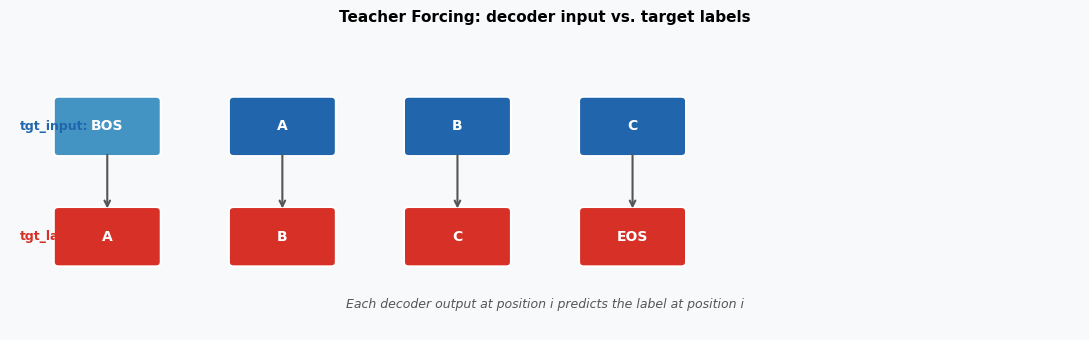

In [10]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.set_xlim(0, 11)
ax.set_ylim(0, 3.5)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

tokens = ["BOS", "A", "B", "C", "EOS"]
colors_in  = ["#4393c3", "#2166ac", "#2166ac", "#2166ac", "#aaaaaa"]
colors_out = ["#aaaaaa", "#d73027", "#d73027", "#d73027", "#d73027"]

for i, (tok, cin, cout) in enumerate(zip(tokens, colors_in, colors_out)):
    x = 1.0 + i * 1.8
    # Decoder input (top row)
    if i < 4:
        rect = mpatches.FancyBboxPatch((x-0.5, 2.1), 1.0, 0.6,
            boxstyle="round,pad=0.05", facecolor=cin, edgecolor="white", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x, 2.4, tok, ha="center", va="center", fontsize=10,
                fontweight="bold", color="white")
    # Decoder output labels (bottom row)
    if i > 0:
        xo = 1.0 + (i-1) * 1.8
        rect = mpatches.FancyBboxPatch((xo-0.5, 0.8), 1.0, 0.6,
            boxstyle="round,pad=0.05", facecolor=cout, edgecolor="white", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(xo, 1.1, tok, ha="center", va="center", fontsize=10,
                fontweight="bold", color="white")
        # arrow
        ax.annotate("", xy=(xo, 1.4), xytext=(xo, 2.1),
            arrowprops=dict(arrowstyle="->", color="#555555", lw=1.5))

ax.text(0.1, 2.4, "tgt_input:", ha="left", va="center", fontsize=9,
        fontweight="bold", color="#2166ac")
ax.text(0.1, 1.1, "tgt_labels:", ha="left", va="center", fontsize=9,
        fontweight="bold", color="#d73027")
ax.text(5.5, 0.3, "Each decoder output at position i predicts the label at position i",
        ha="center", va="center", fontsize=9, color="#555555", style="italic")
ax.set_title("Teacher Forcing: decoder input vs. target labels", fontsize=11,
             fontweight="bold", pad=8)
plt.tight_layout()
plt.show()

## Training Step: Computing the Loss

With teacher forcing in place, a single training step is straightforward:

1. Split the target into `tgt_input` and `tgt_labels`
2. Run `transformer(src, tgt_input)` → logits
3. Compute **cross-entropy loss** between logits and `tgt_labels`
4. Backpropagate and update weights

The loss measures how surprised the model is by the correct next token — lower is better. **Perplexity** (e<sup>loss</sup>) is the exponential of the loss and is the standard evaluation metric for language models: a perplexity of *P* means the model is as uncertain as if it had to choose uniformly among *P* options.

In [11]:
# Example target sequence: [BOS, token_A, token_B, token_C, token_D, EOS]
src_ex      = torch.randint(3, SRC_VOCAB_SIZE, (1, 8))
tgt_full_ex = torch.tensor([[BOS_ID, 45, 123, 67, 89, 200, EOS_ID]])

# Teacher forcing split
tgt_input_ex  = tgt_full_ex[:, :-1]   # [BOS, 45, 123, 67, 89, 200]  — decoder input
tgt_labels_ex = tgt_full_ex[:, 1:]    # [45, 123, 67, 89, 200, EOS]   — what to predict

print(f"src:        {src_ex.tolist()[0]}")
print(f"tgt_input:  {tgt_input_ex.tolist()[0]}")
print(f"tgt_labels: {tgt_labels_ex.tolist()[0]}")

# Forward pass
transformer.train()
logits_ex, _, _, _ = transformer(src_ex, tgt_input_ex)
# logits_ex: (1, tgt_len, vocab_size)

# Loss
loss = F.cross_entropy(
    logits_ex.view(-1, TGT_VOCAB_SIZE),   # (tgt_len, vocab_size)
    tgt_labels_ex.view(-1),               # (tgt_len,)
)
perplexity = torch.exp(loss)

print(f"\nlogits shape:  {tuple(logits_ex.shape)}")
print(f"Loss:          {loss.item():.4f}")
print(f"Perplexity:    {perplexity.item():.2f}")
print(f"\n(Untrained model → loss ≈ log(vocab_size) = {np.log(TGT_VOCAB_SIZE):.2f},",
      f"perplexity ≈ {TGT_VOCAB_SIZE})")

src:        [878, 540, 464, 169, 652, 401, 306, 493]
tgt_input:  [1, 45, 123, 67, 89, 200]
tgt_labels: [45, 123, 67, 89, 200, 2]

logits shape:  (1, 6, 1000)
Loss:          7.2808
Perplexity:    1452.18

(Untrained model → loss ≈ log(vocab_size) = 6.91, perplexity ≈ 1000)


## Autoregressive Inference

At **test time**, there are no ground-truth target tokens to feed the decoder. Instead, the model generates the output sequence **one token at a time**:

1. Encode the source sequence → `encoder_output`
2. Start with `generated = [BOS]`
3. Feed `generated` as the decoder input → get logits for the next position
4. Pick the highest-probability token (`argmax`) — this is **greedy decoding**
5. Append it to `generated` and repeat from step 3
6. Stop when `EOS` is produced or a maximum length is reached

This loop is called **autoregressive generation**. The key observation: `encoder_output` is computed **once** and reused at every step. Only the decoder runs at each iteration.

In [12]:
@torch.no_grad()
def greedy_decode(model, src, bos_id=BOS_ID, eos_id=EOS_ID, max_new_tokens=20):
    """
    Autoregressively generate a target sequence from a source sequence.

    Args:
        model:          Transformer instance
        src:            (1, src_len) — source token IDs (batch size must be 1)
        bos_id:         beginning-of-sequence token ID
        eos_id:         end-of-sequence token ID
        max_new_tokens: maximum number of tokens to generate

    Returns:
        generated: list of token IDs (including BOS, possibly including EOS)
    """
    model.eval()
    # Step 1: encode source once
    encoder_output, _ = model.encode(src)

    generated = [bos_id]

    for step in range(max_new_tokens):
        # Step 2: decode the tokens generated so far
        tgt = torch.tensor([generated])
        logits, _, _ = model.decode(tgt, encoder_output)

        # Step 3: greedy pick — highest-probability token at the last position
        next_token = logits[0, -1].argmax().item()
        generated.append(next_token)

        # Step 4: stop if EOS is generated
        if next_token == eos_id:
            break

    return generated

In [13]:
# Run greedy decoding on a dummy source sequence
src_infer = torch.randint(3, SRC_VOCAB_SIZE, (1, 6))
generated  = greedy_decode(transformer, src_infer, max_new_tokens=10)

print("Source tokens:    ", src_infer.tolist()[0])
print("Generated tokens: ", generated)
print(f"\nGeneration stopped at step {len(generated)-1}",
      "(EOS)" if generated[-1] == EOS_ID else "(max length reached)")

Source tokens:     [578, 541, 759, 352, 315, 409]
Generated tokens:  [1, 108, 585, 211, 384, 520, 470, 1, 604, 773, 280]

Generation stopped at step 10 (max length reached)


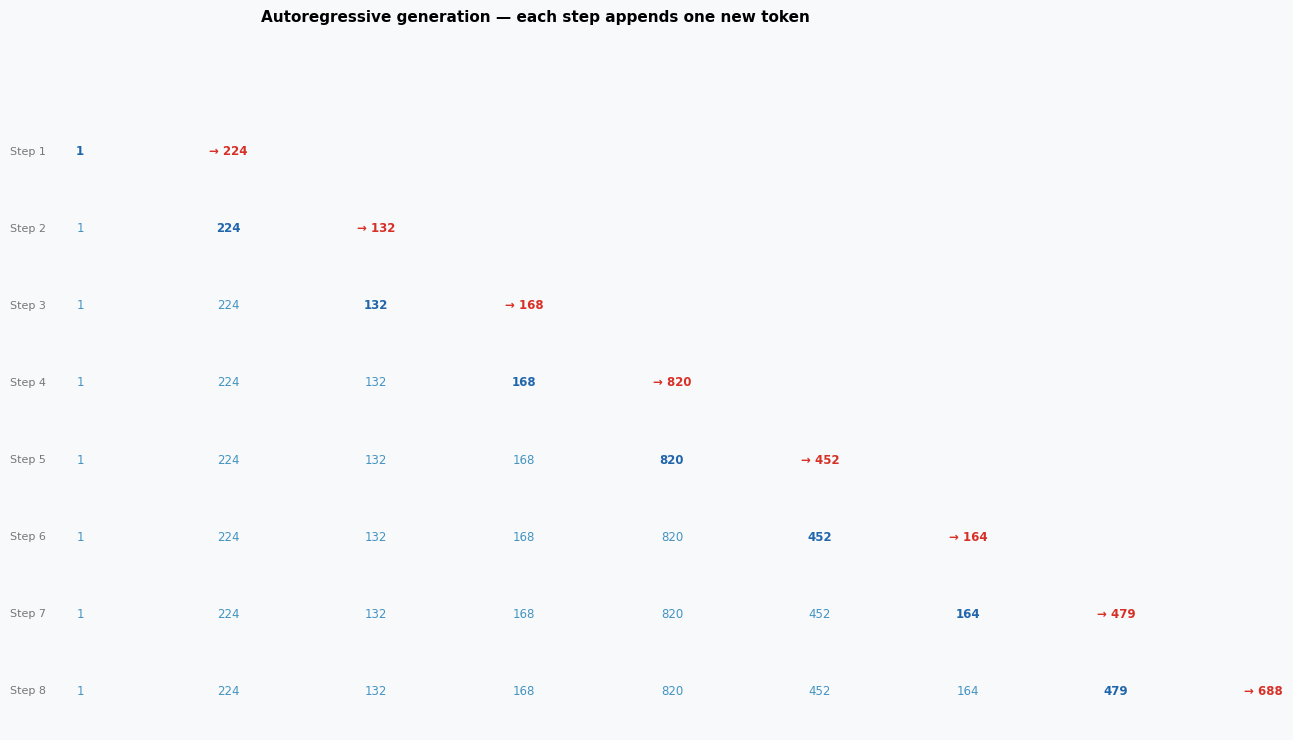

In [14]:
# Visualize the autoregressive generation process step-by-step
src_vis   = torch.randint(3, SRC_VOCAB_SIZE, (1, 5))
max_steps = 8
step_seqs = []

transformer.eval()
encoder_output_vis, _ = transformer.encode(src_vis)
generated_vis = [BOS_ID]

with torch.no_grad():
    for step in range(max_steps):
        tgt_vis = torch.tensor([generated_vis])
        logits_vis, _, _ = transformer.decode(tgt_vis, encoder_output_vis)
        next_tok = logits_vis[0, -1].argmax().item()
        step_seqs.append(generated_vis + ["→ " + str(next_tok)])
        generated_vis.append(next_tok)
        if next_tok == EOS_ID:
            break

# Plot the step-by-step generation
fig, ax = plt.subplots(figsize=(13, len(step_seqs) * 0.75 + 1.5))
ax.set_xlim(-0.5, max_steps + 0.5)
ax.set_ylim(-0.5, len(step_seqs) + 0.5)
ax.axis("off")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

for row, seq in enumerate(step_seqs):
    y = len(step_seqs) - row - 1
    for col, tok in enumerate(seq):
        is_new = (col == len(seq) - 2)      # second-to-last = newly added
        is_pred = str(tok).startswith("→")  # prediction arrow
        color = "#d73027" if is_pred else ("#2166ac" if is_new else "#4393c3")
        fsize = 8.5
        ax.text(col * 1.3, y, str(tok), ha="center", va="center",
                fontsize=fsize, fontweight="bold" if (is_new or is_pred) else "normal",
                color=color)

    ax.text(-0.3, y, f"Step {row+1}", ha="right", va="center",
            fontsize=8, color="#777777")

ax.set_title("Autoregressive generation — each step appends one new token",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

## Visualizing Attention Patterns

The complete Transformer exposes three distinct attention weight matrices at each layer:

| Attention type | Where it lives | What it shows |
|----------------|---------------|---------------|
| Encoder self-attention | Encoder blocks | How source tokens relate to each other |
| Decoder masked self-attention | Decoder blocks | How target tokens attend to previous target tokens (causal) |
| Decoder cross-attention | Decoder blocks | Which source tokens each target token focuses on |

We'll run a forward pass and visualize all three.

In [15]:
src_attn = torch.randint(3, SRC_VOCAB_SIZE, (1, 7))   # source: 7 tokens
tgt_attn = torch.randint(3, TGT_VOCAB_SIZE, (1, 5))   # target: 5 tokens

transformer.eval()
with torch.no_grad():
    _, enc_attn, self_attn, cross_attn = transformer(src_attn, tgt_attn)

# Use the last encoder / decoder layer for visualization
enc_w   = enc_attn[-1][0]     # (num_heads, src_len, src_len)
sa_w    = self_attn[-1][0]    # (num_heads, tgt_len, tgt_len)
ca_w    = cross_attn[-1][0]   # (num_heads, tgt_len, src_len)

print(f"Encoder self-attention:   {tuple(enc_w.shape)}  (heads, src_len, src_len)")
print(f"Decoder masked self-attn: {tuple(sa_w.shape)}  (heads, tgt_len, tgt_len)")
print(f"Decoder cross-attention:  {tuple(ca_w.shape)}  (heads, tgt_len, src_len)")

Encoder self-attention:   (4, 7, 7)  (heads, src_len, src_len)
Decoder masked self-attn: (4, 5, 5)  (heads, tgt_len, tgt_len)
Decoder cross-attention:  (4, 5, 7)  (heads, tgt_len, src_len)


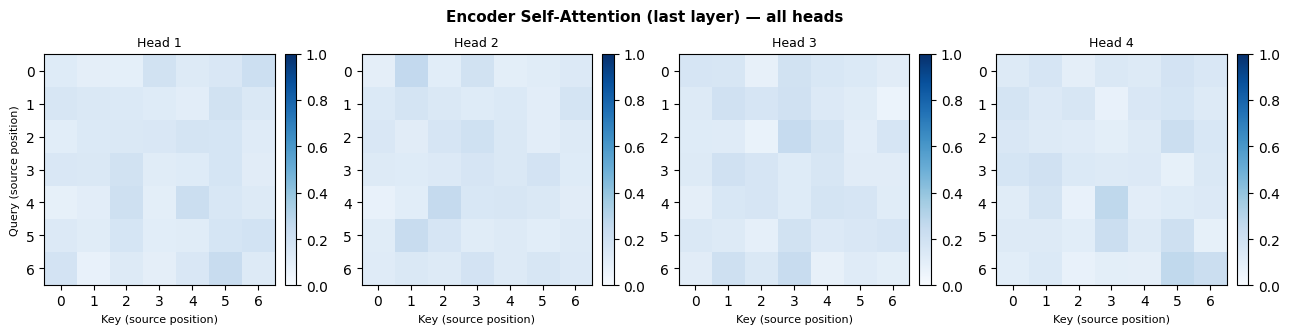

In [16]:
# ── 1. Encoder self-attention (head 0, last layer) ──────────────────────
fig, axes = plt.subplots(1, NUM_HEADS, figsize=(13, 3.2))
fig.suptitle("Encoder Self-Attention (last layer) — all heads", fontsize=11, fontweight="bold")

for h in range(NUM_HEADS):
    im = axes[h].imshow(enc_w[h].numpy(), cmap="Blues", vmin=0, vmax=1)
    axes[h].set_title(f"Head {h+1}", fontsize=9)
    axes[h].set_xlabel("Key (source position)", fontsize=8)
    if h == 0:
        axes[h].set_ylabel("Query (source position)", fontsize=8)
    axes[h].set_xticks(range(src_attn.size(1)))
    axes[h].set_yticks(range(src_attn.size(1)))
    plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

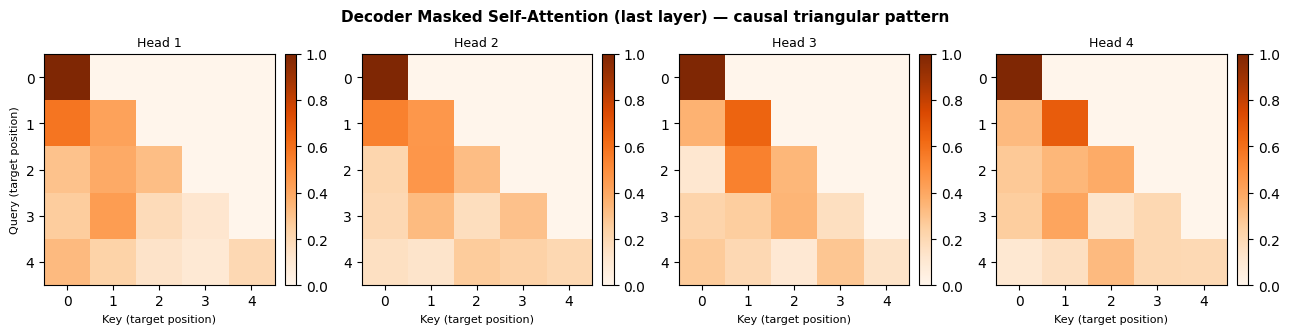

In [17]:
# ── 2. Decoder masked self-attention (head 0, last layer) ───────────────
fig, axes = plt.subplots(1, NUM_HEADS, figsize=(13, 3.2))
fig.suptitle("Decoder Masked Self-Attention (last layer) — causal triangular pattern",
             fontsize=11, fontweight="bold")

for h in range(NUM_HEADS):
    im = axes[h].imshow(sa_w[h].numpy(), cmap="Oranges", vmin=0, vmax=1)
    axes[h].set_title(f"Head {h+1}", fontsize=9)
    axes[h].set_xlabel("Key (target position)", fontsize=8)
    if h == 0:
        axes[h].set_ylabel("Query (target position)", fontsize=8)
    axes[h].set_xticks(range(tgt_attn.size(1)))
    axes[h].set_yticks(range(tgt_attn.size(1)))
    plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

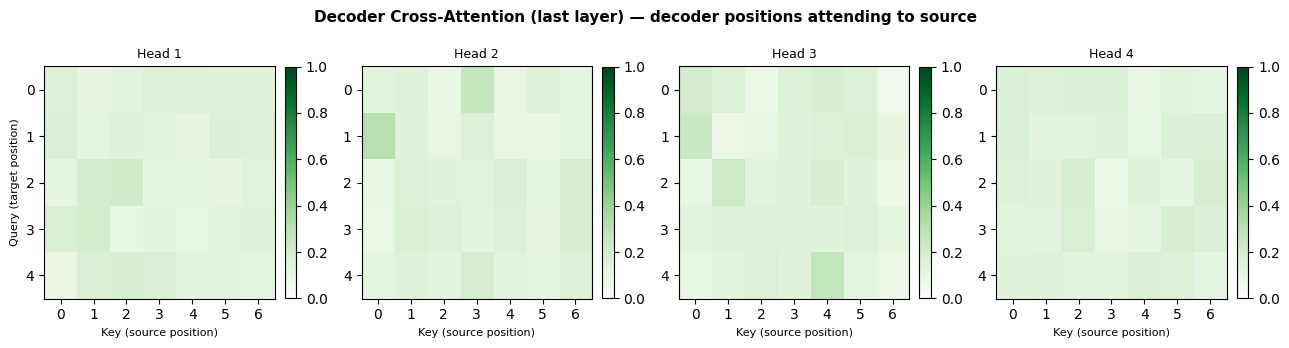

In [18]:
# ── 3. Decoder cross-attention (last layer) ──────────────────────────────
fig, axes = plt.subplots(1, NUM_HEADS, figsize=(13, 3.5))
fig.suptitle("Decoder Cross-Attention (last layer) — decoder positions attending to source",
             fontsize=11, fontweight="bold")

for h in range(NUM_HEADS):
    im = axes[h].imshow(ca_w[h].numpy(), cmap="Greens", vmin=0, vmax=1,
                        aspect="auto")
    axes[h].set_title(f"Head {h+1}", fontsize=9)
    axes[h].set_xlabel("Key (source position)", fontsize=8)
    if h == 0:
        axes[h].set_ylabel("Query (target position)", fontsize=8)
    axes[h].set_xticks(range(src_attn.size(1)))
    axes[h].set_yticks(range(tgt_attn.size(1)))
    plt.colorbar(im, ax=axes[h], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

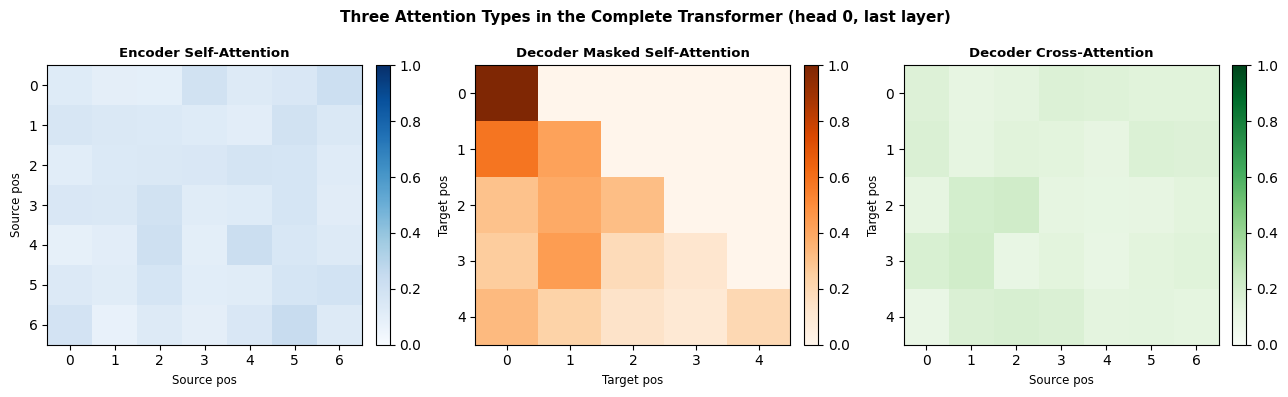

In [19]:
# ── 4. Side-by-side summary: all three attention types in one figure ─────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Three Attention Types in the Complete Transformer (head 0, last layer)",
             fontsize=11, fontweight="bold")

panels = [
    (enc_w[0].numpy(), "Blues",   "Encoder Self-Attention",
     "Source pos", "Source pos"),
    (sa_w[0].numpy(),  "Oranges", "Decoder Masked Self-Attention",
     "Target pos", "Target pos"),
    (ca_w[0].numpy(),  "Greens",  "Decoder Cross-Attention",
     "Source pos", "Target pos"),
]

for ax, (data, cmap, title, xlabel, ylabel) in zip(axes, panels):
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_title(title, fontsize=9.5, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=8.5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### Key Takeaways

- The **complete Transformer** combines encoder and decoder into a single model for sequence-to-sequence tasks (translation, summarization, etc.)
- The **encoder** reads the full source sequence and produces a contextualized memory — a matrix of shape `(src_len, d_model)` that the decoder can query
- The **decoder** generates the target sequence one token at a time, guided by two information sources:
  1. Its own past outputs (via **masked self-attention**)
  2. The encoder's memory (via **cross-attention**)
- **Teacher forcing** feeds ground-truth previous tokens to the decoder during training — this stabilizes learning but creates a discrepancy with inference (where predictions are fed back instead)
- **Greedy decoding** always picks the highest-probability token at each step; more advanced strategies (top-k, nucleus/top-p, beam search) are covered in the next notebook
- Separating `encode()` and `decode()` into distinct methods makes inference efficient — the encoder runs **once**, the decoder runs **once per token**

### Comparison: Original Paper vs. Our Implementation

| Component | Original Paper (Vaswani et al.) | Our Implementation |
|-----------|--------------------------------|--------------------|
| d_model | 512 | 64 |
| num_heads | 8 | 4 |
| d_ff | 2048 | 256 |
| num_layers (enc + dec) | 6 + 6 | 4 + 4 |
| Positional Encoding | Sinusoidal | Sinusoidal |
| Encoder attention | Bidirectional | Bidirectional |
| Decoder self-attention | Causal (masked) | Causal (masked) |
| Decoder cross-attention | Encoder → Decoder | Encoder → Decoder |
| Normalization | Post-norm | Post-norm |
| Dropout | 0.1 | 0.1 |
| Task | Machine Translation (EN→DE) | — (architecture demo) |

The architecture is **identical** to the original — only the dimensions are scaled down for demonstration purposes. To replicate the full paper, increase `d_model`, `num_heads`, `d_ff`, and `num_layers`.